# Yearly Salary Linear Regression

Start from the beginning and write the code yourself.


In [61]:
import pandas as pd
import numpy as np

In [62]:
salary = pd.read_csv("data/Salary_dataset.csv")
print(salary.head())
print(salary.shape)
print(salary.columns.tolist())

   Unnamed: 0  YearsExperience   Salary
0           0              1.2  39344.0
1           1              1.4  46206.0
2           2              1.6  37732.0
3           3              2.1  43526.0
4           4              2.3  39892.0
(30, 3)
['Unnamed: 0', 'YearsExperience', 'Salary']


In [63]:
X = salary.drop(columns=["Salary"])
y = salary["Salary"]

In [64]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

print(X_test)

    Unnamed: 0  YearsExperience
27          27              9.7
15          15              5.0
23          23              8.3
17          17              5.4
8            8              3.3
9            9              3.8


In [65]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[ -852.63,12045.98]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](2,)","['Unnamed: 0','YearsExperience']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.245e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,2


In [66]:
y_pred = model.predict(X_test)
print(y_pred)

[116277.37185839  69892.77988271 102823.5044592   73005.91971544
  55382.99660129  60553.36038452]


In [67]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

print(comparison)

      Actual      Predicted
27  112636.0  116277.371858
15   67939.0   69892.779883
23  113813.0  102823.504459
17   83089.0   73005.919715
8    64446.0   55382.996601
9    57190.0   60553.360385


In [68]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)
print(mae)

6515.681891615336


In [69]:
score = model.score(X_test, y_test)
print(score)

0.8913575982179494


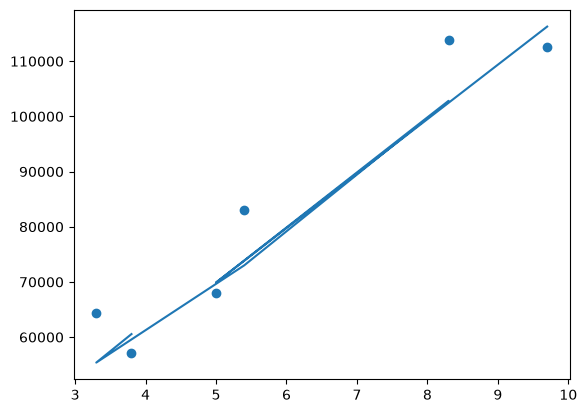

In [70]:
import matplotlib.pyplot as plt

plt.scatter(X_test["YearsExperience"], y_test)
plt.plot(X_test["YearsExperience"], y_pred)
plt.show()

In [71]:
from sklearn.metrics import mean_absolute_error, r2_score

print(mean_absolute_error(y_test, y_pred))
print(r2_score(y_test, y_pred))

6515.681891615336
0.8913575982179494
